In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("main_data_filled.csv")

# Ensure proper data types
df['Block'] = df['Block'].astype(str)
df['congruency'] = df['congruency'].astype(str)

# Compute mean accuracy per Block × congruency × st_iter
learning_summary = (
    df.groupby(['Block', 'congruency', 'st_iter'])
      .agg(accuracy=('correct', 'mean'))
      .reset_index()
)


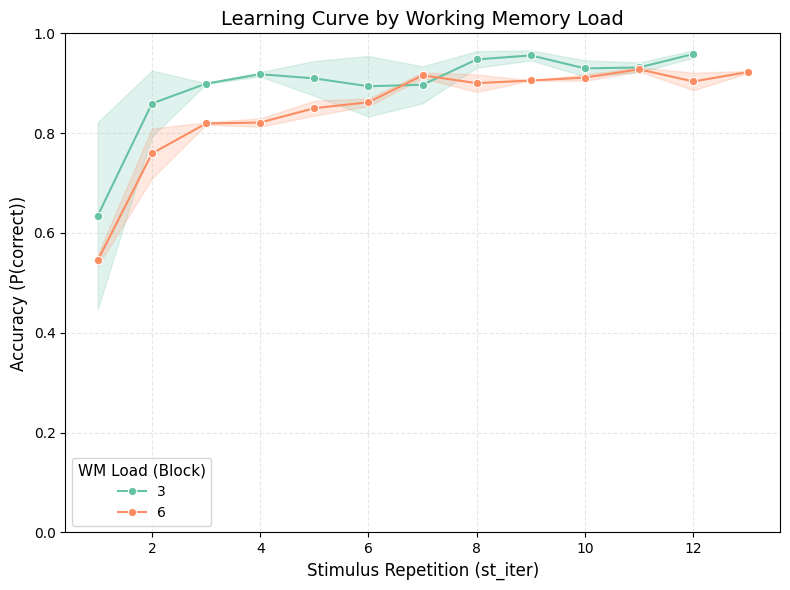

In [5]:
plt.figure(figsize=(8,6))
sns.lineplot(
    data=learning_summary,
    x='st_iter', y='accuracy',
    hue='Block', palette='Set2', marker='o'
)

plt.title('Learning Curve by Working Memory Load', fontsize=14)
plt.xlabel('Stimulus Repetition (st_iter)', fontsize=12)
plt.ylabel('Accuracy (P(correct))', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='WM Load (Block)', title_fontsize=11, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


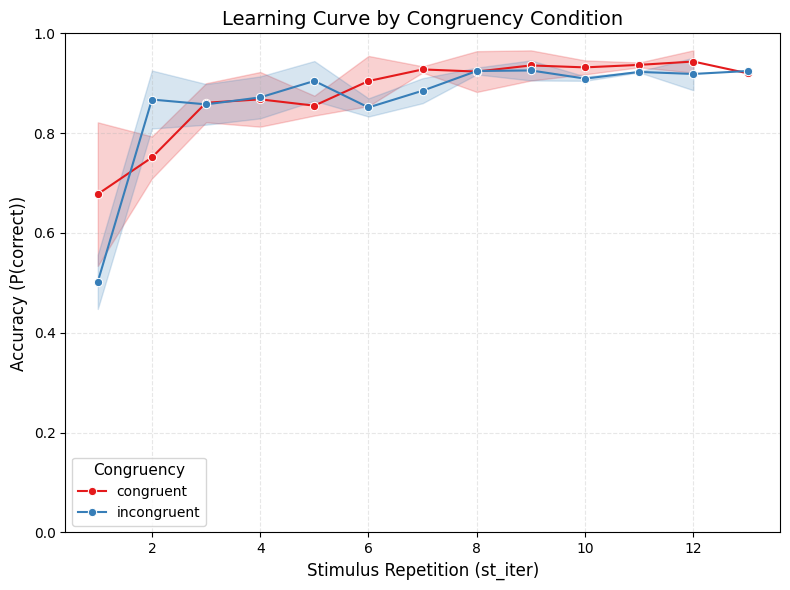

In [6]:
plt.figure(figsize=(8,6))
sns.lineplot(
    data=learning_summary,
    x='st_iter', y='accuracy',
    hue='congruency', palette='Set1', marker='o'
)

plt.title('Learning Curve by Congruency Condition', fontsize=14)
plt.xlabel('Stimulus Repetition (st_iter)', fontsize=12)
plt.ylabel('Accuracy (P(correct))', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='Congruency', title_fontsize=11, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Convert variables to categorical if needed
df['Block'] = df['Block'].astype(str)
df['congruency'] = df['congruency'].astype(str)

In [8]:
acc_block = (
    df.groupby('Block')
      .agg(mean_accuracy=('correct', 'mean'),
           sd=('correct', 'std'),
           n=('correct', 'size'))
      .reset_index()
)

# Compute standard error and 95% CI
acc_block['se'] = acc_block['sd'] / (acc_block['n'] ** 0.5)
acc_block['ci95'] = 1.96 * acc_block['se']

print("=== Mean Accuracy by WM Load (Block) ===")
print(acc_block)


=== Mean Accuracy by WM Load (Block) ===
  Block  mean_accuracy        sd      n        se      ci95
0     3       0.896054  0.305208   9072  0.003204  0.006281
1     6       0.849359  0.357711  14040  0.003019  0.005917


In [9]:
acc_cong = (
    df.groupby('congruency')
      .agg(mean_accuracy=('correct', 'mean'),
           sd=('correct', 'std'),
           n=('correct', 'size'))
      .reset_index()
)

acc_cong['se'] = acc_cong['sd'] / (acc_cong['n'] ** 0.5)
acc_cong['ci95'] = 1.96 * acc_cong['se']

print("\n=== Mean Accuracy by Congruency ===")
print(acc_cong)



=== Mean Accuracy by Congruency ===
    congruency  mean_accuracy        sd      n        se      ci95
0    congruent       0.874968  0.330770  11597  0.003072  0.006020
1  incongruent       0.860356  0.346632  11515  0.003230  0.006331


In [10]:
acc_combo = (
    df.groupby(['Block', 'congruency'])
      .agg(mean_accuracy=('correct', 'mean'),
           sd=('correct', 'std'),
           n=('correct', 'size'))
      .reset_index()
)

acc_combo['se'] = acc_combo['sd'] / (acc_combo['n'] ** 0.5)
acc_combo['ci95'] = 1.96 * acc_combo['se']

print("\n=== Mean Accuracy by Block × Congruency ===")
print(acc_combo)



=== Mean Accuracy by Block × Congruency ===
  Block   congruency  mean_accuracy        sd     n        se      ci95
0     3    congruent       0.922791  0.266952  4572  0.003948  0.007738
1     3  incongruent       0.868889  0.337559  4500  0.005032  0.009863
2     6    congruent       0.843843  0.363030  7025  0.004331  0.008489
3     6  incongruent       0.854882  0.352244  7015  0.004206  0.008243
